## Cyber Security of Software Systems
### Course Project: Intrusion detector
#### Part 1: Data Fetch & Train ANN

In [ ]:
# Data have to be downloaded first
# install tools to download data
!pip install awscli --upgrade --no-cache-dir

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following packages were automatically installed and are no longer required:
  docutils-common fonts-droid-fallback fonts-noto-mono ghostscript groff
  gsfonts imagemagick imagemagick-6-common imagemagick-6.q16 libdjvulibre-text
  libdjvulibre21 libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35
  libimagequant0 libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0
  libmagickcore-6.q16-6 libmagickcore-6.q16-6-extra libmagickwand-6.q16-6
  libnetpbm10 libraqm0 libwmflite-0.2-7 netpbm psutils python3-botocore
  python3-certifi python3-chardet python3-colorama python3-dateutil
  python3-docutils python3-idna python3-jmespath python3-olefile python3-pil
  python3-pyasn1 python3-requests python3-roman python3-rsa python3-s3transfer
  python3-urllib3 sgml-base xml-core
Use 'apt autoremove' to remove them.
The following packages will be REMOVED:
  awscli
0 upgraded, 0 newly installed, 1 to remo

In [ ]:
# check the aws location
!aws s3 ls --no-sign-request s3://cse-cic-ids2018/

                           PRE Original Network Traffic and Log data/
                           PRE Processed Traffic Data for ML Algorithms/


In [ ]:
#check what's in the folder 'PRE Processed Traffic Data for ML Algorithms/'
!aws s3 ls --no-sign-request "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/"

2018-10-11 16:02:25          0 
2018-10-11 16:02:49  352368373 Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:03:10  333723605 Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:03:33  382840456 Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:03:59 4054925350 Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:08:38  107842858 Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:08:48  375945899 Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:09:20  382636202 Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:09:44  358223333 Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:10:12  328893673 Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:10:33  209249758 Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


In [ ]:
#install some more stuff. we would like to check out what's in these csv files without downloading at this point
!pip install s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 65.3 MB/s eta 0:00:00
  Attempting uninstall: botocore
    Found existing installation: botocore 1.37.33
    Uninstalling botocore-1.37.33:
      Successfully uninstalled botocore-1.37.33
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3transfer 0.11.4 requires botocore<2.0a.0,>=1.37.4, but you have botocore 1.37.1 which is incompatible.
awscli 1.38.33 requires botocore==1.37.33, but you have botocore 1.37.1 which is incompatible.


In [ ]:
import pandas as pd

# Path to the file in S3
s3_file_path = "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv"

# Read directly into a DataFrame
df = pd.read_csv(s3_file_path)
df.head()  # Show the first 5 rows of the dataframe

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773.0,202,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0.0,38,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527.0,385,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0.0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141.0,517,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [ ]:
import numpy as np

#lets look at this dataset a bit more carefully

# Identify categorical columns (non-numeric)
categorical_cols = df.select_dtypes(include=['object']).columns

# Identify numerical columns (numeric types)
numerical_cols = df.select_dtypes(exclude=['object']).columns

# Display the column names
print(f"Categorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# For each categorical column, calculate value counts and NaN counts
print("\n-------------------------------")
print("Categorical cols:")
print("---------------------------------")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))  # Counts for all values including NaN
    print("\nMissing values:", df[col].isnull().sum())  # Count missing values (NaNs)
    print(f"Contains +inf: {np.isposinf(df[col]).any()}")
    print(f"Contains -inf: {np.isneginf(df[col]).any()}")

# For each numerical column, calculate min, mean, max, and NaN count
print("\n-------------------------------")
print("Numerical cols:")
print("---------------------------------")
for col in numerical_cols:
    print(f"\n--- {col} ---")
    print(f"Min: {df[col].min()}")
    print(f"Mean: {df[col].mean()}")
    print(f"Max: {df[col].max()}")
    print(f"Missing values: {df[col].isnull().sum()}")  # Count missing values (NaNs)
    print(f"Contains +inf: {np.isposinf(df[col]).any()}")
    print(f"Contains -inf: {np.isneginf(df[col]).any()}")

Categorical Columns: Index([], dtype='object')
Numerical Columns: Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'E

In [ ]:
# lets download the data before doing any analysis

#mount drive
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
#create a folder where the data is saved at
!mkdir -p "/content/drive/My Drive/CIC_IDS2018"

In [ ]:
# save the previosly previewed file to this folder
!aws s3 cp --no-sign-request "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv" "/content/drive/My Drive/CIC_IDS2018/"

download: s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv to drive/My Drive/CIC_IDS2018/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv


In [ ]:
# load the data from the saved storage
df = pd.read_csv("/content/drive/My Drive/CIC_IDS2018/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv")

In [ ]:
# make sure it works
print(df.head())
print(df.tail())
print(df.columns)

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0       443         6  02/03/2018 08:47:38         141385             9   
1     49684         6  02/03/2018 08:47:38            281             2   
2       443         6  02/03/2018 08:47:40         279824            11   
3       443         6  02/03/2018 08:47:40            132             2   
4       443         6  02/03/2018 08:47:41         274016             9   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             7              553           3773.0              202   
1             1               38              0.0               38   
2            15             1086          10527.0              385   
3             0                0              0.0                0   
4            13             1285           6141.0              517   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                20          0.0    

In [ ]:

# pre-process the data a bit...

# we can drop the Timestamp since this is only for friday's data at this point,
# that being said maybe time of day of an attack is somewhat universal and could
# be a useful predictor; we also drop 'Flow Byts/s' and 'Flow Pkts/s' since these
# were the only columns to have nan and inf values in them. (we'll come back
# to dealing with missing data and imputation if these columns turn out out
# to be important!)
df = df.drop(['Timestamp', 'Flow Byts/s', 'Flow Pkts/s'] , axis=1)

# Convert labels to binary: 1 = attack, 0 = benign
df['Label'] = df['Label'].apply(lambda x: 0 if 'BENIGN' in x.upper() else 1)

from sklearn.model_selection import train_test_split

# Assuming df is already cleaned and 'Label' is the target
X = df.drop('Label', axis=1)
y = df['Label']

In [ ]:
# split to train and test sets
test_size = 0.2
random_state = 1234

#note: the labels are very imbalanced so use the stratify option
stratify = True
if stratify:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, \
                                                    stratify=y)
else:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

In [ ]:
#Use techniques like SMOTE (Synthetic Minority Over-Sampling Technique)
#or simple duplication to increase the representation of the minority
#class in the training set. This works well when class weighting isn't sufficient.
#from imblearn.over_sampling import SMOTE

#smote = SMOTE()
#X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [ ]:
#save test data locally
#X_test.to_csv('/content/drive/My Drive/CIC_IDS2018/X_test.csv', index=False)
#y_test.to_csv('/content/drive/My Drive/CIC_IDS2018/y_test.csv', index=False)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create and fit the scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Use the SAME scaler to transform test data
X_test_scaled = scaler.transform(X_test)

#save the scaler to drive
import joblib

# Save the scaler to Drive or local disk
joblib.dump(scaler, '/content/drive/My Drive/CIC_IDS2018/scaler.pkl')
#scaler = joblib.load('/content/drive/My Drive/CIC_IDS2018/scaler.pkl')

In [ ]:
# Build the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout  # Import Dropout layer
from tensorflow.keras.callbacks import EarlyStopping

# Build the ANN model with Dropout and Early Stopping
model = Sequential()

# Input layer and first hidden layer with Dropout
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.3))  # Dropout with 30% rate

# Second hidden layer with Dropout
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))  # Dropout with 30% rate

# Output layer (for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model architecture
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,153 (35.75 KB)

 Trainable params: 9,153 (35.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train model!

# EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping and validation data (20%)
history = model.fit(X_train_scaled, y_train, epochs=25, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print(f"Test accuracy: {test_accuracy:.4f}")


Epoch 1/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - accuracy: 0.9933 - loss: 0.0217 - val_accuracy: 0.9998 - val_loss: 7.5935e-04
Epoch 2/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 59s 3ms/step - accuracy: 0.9996 - loss: 0.0024 - val_accuracy: 0.9998 - val_loss: 0.0013
Epoch 3/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9998 - val_loss: 0.0011
Epoch 4/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 0.9998 - val_loss: 5.9909e-04
Epoch 5/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9999 - val_loss: 3.4799e-04
Epoch 6/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9998 - loss: 0.0014 - val_accuracy: 0.9999 - val_loss: 6.4345e-04
Epoch 7/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9999 - val_loss: 4.7337e-04
Epoch 8/25
20972/20972 ━━━━━━━━━━━━━━━━━━━━ 80s 3

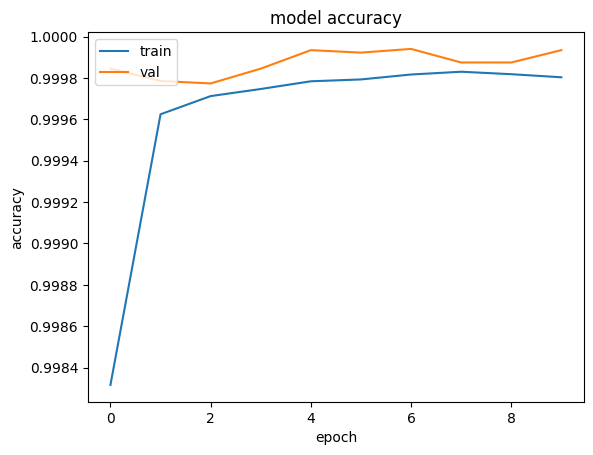

In [ ]:
# plot train and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9999 - loss: 3.8072e-04
Test Loss: 0.0005
Test Accuracy: 0.9999
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    152477
           1       1.00      1.00      1.00     57238

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



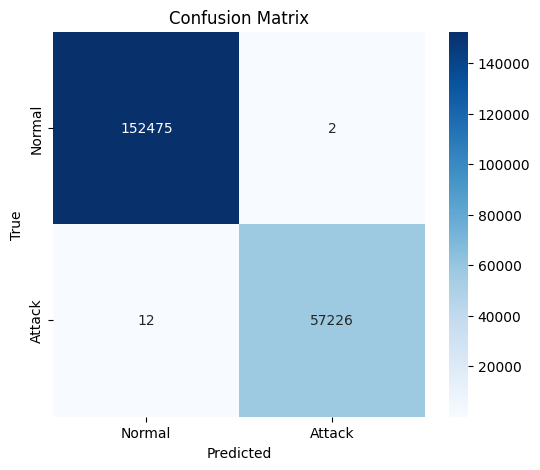

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Step 2: Make predictions on the test set
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

# Step 3: Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 4: Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Save the trained model to Google Drive
#model_path = '/content/drive/My Drive/CIC_IDS2018/cic_ids2018_friday.h5'
model_path = '/content/drive/My Drive/CIC_IDS2018/cic_ids2018_friday.keras'
model.save(model_path)

print(f"Model saved to: {model_path}")

Model saved to: /content/drive/My Drive/CIC_IDS2018/cic_ids2018_friday.keras
